# FoodHub Data Analysis
## Project Foundations for Data Science

### April 17, 2026

---

## Contents

- Executive Summary
- Business Problem Overview and Solution Approach
- Setup & Library Imports
- Data Overview
- EDA - Univariate Analysis
- EDA - Multivariate Analysis
- Conclusions and Recommendations
- Appendix - Data Dictionary

---

## Executive Summary

### Key Findings
- The majority of orders cost $20 or less (70%)
- The top 5 restaurants account for more than a third of all orders (34%)
- Weekend orders are the highest volume of all order activity (71.2%)
- American and Japanese cuisine dominate weekend orders (56%)
- A significant number of orders go unrated (38.8%) which could provide additional insight into customer satisfaction
- Nothing in the current ratings analysis identifies any meaningful relationship driving customer satisfaction

### Recommendations
- Review compensation structure to align with the cost of each order and increase revenue. 
    - Incentivize orders more than $20
    - Increase compensation on orders $20 or less
- Analyze weekend activity further to see if there are successes that can be mirrored throughout the weekdays
- Prioritize the top restaurants and/or cuisines with promotions to drive higher order volume
- Develop promotions/incentives to drive higher order volume during the weekdays
- Review ratings questions and gathering processes to obtain better quality data and higher ratings volume to deepen 
understanding of customer satisfaction.

---

## Business Problem Overview and Solution Approach

### Business Context

FoodHub is a food delivery aggregator operating in New York City. 
The platform connects customers with multiple restaurants through a 
single mobile app. The app manages the full order lifecycle, from 
customer placement, to restaurant confirmation, to delivery person 
assignment, to final drop-off and customer rating.

FoodHub generates revenue by collecting a fixed margin
from restaurants on each completed order.

### Business Problem

As the number of NYC restaurants grows and demand for food delivery 
increases, particularly among students and busy professionals,
FoodHub needs to understand which restaurants, cuisines, and ordering 
patterns drive the most demand.

Without this understanding, FoodHub cannot:
- Identify which restaurants to prioritize for partnership and promotion
- Understand peak demand periods to optimize delivery staffing
- Address gaps in customer satisfaction (ratings, delivery time)
- Maximize revenue from its compensation structure

### Objective

The Data Science team has been asked to analyze historical order data 
to answer key business questions and provide recommendations that will 
help the company improve customer experience and business performance.

### Solution Approach and Methodology

This analysis follows a structured EDA (Exploratory Data Analysis) approach:
1. Data Understanding: Examine structure, data types, missing values, and summary statistics
2. Univariate Analysis: Explore variables individually to understand distributions
3. Multivariate Analysis: Examine relationships between variables to uncover patterns
4. Business Analysis: Answer specific business questions posed by the Data Science team
5. Conclusions: Translate findings into useful business recommendations

Tools Used: Python 3, pandas, NumPy, Matplotlib, Seaborn

---

## Setup & Library Imports

### Importing Libraries

The first line suppresses warnings so the notebook output is easier to read.

The following libraries are imported for the analysis:
- numpy - this handles the numerical operations and arrays
- pandas - this helps with loading, cleaning and manipulating the data in a tabular or table format
- matplotlib - one of the libraries available that allows us to visualize the data in different formats
- seaborn - built on matplotlib to help us produce cleaner visualizations, often with fewer lines of code

Lastly, the final line makes sure charts display inside the notebook instead of opening in a separate window.

In [233]:
# Suppress warnings to keep the output clean
import warnings
warnings.filterwarnings("ignore")

# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display charts inline within the notebook
%matplotlib inline


--- 

## Data Overview

### Loading the Data and understanding the structure of the data

We load the CSV file into pandas DataFrame ('df') using 'pd.read_csv()'
The 'df.head()' allows us to preview the first 5 rows of data so we
can confirm the data is loaded correctly and see what data we are working with.

In [234]:
# Load the CSV file into a new DataFrame called df
df = pd.read_csv('foodhub_order.csv')

# Preview the first 5 rows to confirm the data loaded correctly
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.7500,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.0800,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.2300,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.2000,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.5900,Weekday,4,25,24


#### Observations:

The DataFrame displays 9 columns, consistent with the Data Dictionary 
in the Appendix. Each row represents a single customer order containing 
details about the restaurant, cuisine, cost, timing, and rating.

Notable at first glance, the **rating** column shows **Not given** for 
some orders rather than a numeric value. This will be examined further 
in the analysis.

---

### **Question 1:** How many rows and columns are present in the data?

In [235]:
# df.shape returns a tuple (number of rows, number of columns)
# print with f-string formatting for better readability

print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset has 1898 rows and 9 columns.


#### Observations

- The dataset contains **1,898 rows**, where each row represents a 
   single customer order placed through the FoodHub platform.

- There are **9 columns**, where each column represents a specific 
   attribute of that order such as restaurant, cuisine, cost, 
   timing, and customer rating.

---

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [236]:
# df.info() prints a summary of the DataFrame including: 
# column names, non-null counts, and data types of each column.

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 196.6 KB


In [237]:
# .value_counts(), counts the number of occurrences of each unique value in the df.dtypes

dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f'There are {count} columns of type {dtype}.')

There are 4 columns of type int64.
There are 4 columns of type str.
There are 1 columns of type float64.


#### Observations:
'df.info()' confirms the following about our dataset:
- All 9 columns show 1,898 non-null values so at first glance there are no gaps to address
- The data breaks down as follows:
    - 4 columns with type int64
    - 4 columns with type str.
    - 1 column with type float64.

**Note** Depending on the version of pandas being used, string columns
may display as 'object' instead of 'str'. Both of these represent text
data and should behave in the same manner for analysis

- The 'rating' column includes both numeric and string values. Since pandas is identifying
this as a string value, we may need to address this before doing any numerical analysis on
this column.

- Both 'order_id' and 'customer_id' are integer values but function as labels. Therefore
any statistical analysis on these columns may not provide any value.

---

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.

In [238]:
# isnull() returns True for any null entries and False for non-null entries. 
# .sum adds up these values, so we can get a count per column.

null_counts = df.isnull().sum()
print(null_counts)


order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


#### Observations:
- All 9 columns return a null count of 0, confirming there are no missing values
- Even though there are no null values for 'rating', the 'Not given' response will need to be addressed
to avoid skewing any statistical analysis in this column

---

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [239]:
# df.describe(include="all") generates descriptive statistics for all of the values in the DataFrame.
# .T transposes the output for better readability.This may not be necessary for all datasets, 
# but it can be helpful when there are many columns or when the default orientation is difficult to read.

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0000,NaN,NaN,NaN,1477495.5000,548.0497,1476547.0000,1477021.2500,1477495.5000,1477969.7500,1478444.0000
customer_id,1898.0000,NaN,NaN,NaN,171168.4784,113698.1397,1311.0000,77787.7500,128600.0000,270525.0000,405334.0000
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0000,NaN,NaN,NaN,16.4989,7.4838,4.4700,12.0800,14.1400,22.2975,35.4100
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0000,NaN,NaN,NaN,27.3720,4.6325,20.0000,23.0000,27.0000,31.0000,35.0000
delivery_time,1898.0000,NaN,NaN,NaN,24.1617,4.9726,15.0000,20.0000,25.0000,28.0000,33.0000


In [240]:
# variables are created to store the minimum, maximum, and average food preparation times
# and then print statements like we used above are used to display the results in a more readable format. 

min_prep_time = df['food_preparation_time'].min()
max_prep_time = df['food_preparation_time'].max()
avg_prep_time = df['food_preparation_time'].mean()

print(f'The minimum food preparation time: {min_prep_time} minutes')
print(f'The maximum food preparation time: {max_prep_time} minutes')
print(f'The average food preparation time: {avg_prep_time:.2f} minutes')

The minimum food preparation time: 20 minutes
The maximum food preparation time: 35 minutes
The average food preparation time: 27.37 minutes


#### Q4 Answer

Food preparation time: 
- minimum **20 min**
- maximum **35 min**
- average **27.37 min** 

#### Observations
**Numeric Columns**

There are five numeric columns providing count, mean, standard deviation, 
min, max, and quartile values. Of these only 3 provide statistical value:
- cost_of_the_order
- food_preparation_time
- delivery_time  

These values can give additional insight to our data for example:
The **mean** cost of an order is higher than the **50% (median)** suggesting the 
cost distribution is right-skewed with some higher-value orders 
influencing the average.

**String Columns**

There are 4 string columns providing count, unique value count, 
the most frequent value (top), and its frequency (freq). 
All numeric statistics return NaN for these columns, which is 
expected. This gives us a quick snapshot of categorical 
distribution for example, which restaurant and cuisine type 
appear most often in the dataset.

---

### **Question 5:** How many orders are not rated?

**Analyze the Ratings and address any issues**

In [241]:
# .nunique() returns the number of distinct values in the rating column.
# .unique() returns an array of the unique values in the rating column.

print(f'The number of unique ratings is {df["rating"].nunique()}.')
print()
print(df["rating"].unique())

The number of unique ratings is 4.

<ArrowStringArray>
['Not given', '5', '3', '4']
Length: 4, dtype: str


In [242]:
# Count the number of orders where the rating is 'Not given'
not_rated = df[df.rating == 'Not given'].rating.count()

# Determine the % of orders that were not rated
not_rated_percentage = (not_rated / len(df) * 100)

print(f'The number of orders that were rated Not given is {not_rated}.')
print(f'The percentage of orders that were not rated Not given is {not_rated_percentage:.1f}%')

The number of orders that were rated Not given is 736.
The percentage of orders that were not rated Not given is 38.8%


**Address the text values found in the rating column**

In [243]:
# pd.to_numeric() is used to convert the numeric values to a consistent data type
# errors="coerce" tells it to convert non-numeric values to NaN.

df['rating_numeric'] = pd.to_numeric(df['rating'], errors='coerce') # Create a new column 'rating_numeric' with the converted values

# Confirm that the conversion worked by checking the data type of the 'rating' column
print(f'NaN count after conversion: {df["rating_numeric"].isna().sum()}')
print()
print(df['rating_numeric'].unique())

NaN count after conversion: 736

[nan  5.  3.  4.]


#### Observations

The rating column contains four distinct values: **3**, **4**, **5**, 
and **Not given**. Of the 1,898 orders, **736 (38.8%)** were not rated 
by the customer.

Interestingly, there were no ratings of 1 or 2 in the dataset. This may suggest 
either that there were very few poor experiences or perhaps those who had a poor experience chose 'Not given'
instead of a formal poor rating.

We converted the rating column to a numeric value. We replaced 'Not given' with NaN. This 
will be used for all numeric rating analysis going forward.

---

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)

#### Order ID (order_id)

In [244]:
# order_id is a unique identifier for each order and not a measurement.
# We confirm this by checking the number of unique order_id values and comparing it to the total number of rows

print(f'The total number of orders is {len(df)}.')
print(f'The number of unique order IDs is {df["order_id"].nunique()}.')
print(f'The number of duplicate order IDs is {len(df) - df["order_id"].nunique()}.')


The total number of orders is 1898.
The number of unique order IDs is 1898.
The number of duplicate order IDs is 0.


#### Observations

'order_id' is a unique row identifier and carries no statistical or 
analytical value. The column contains **1,898 unique values**, one 
per order, confirming there are no duplicate records in the dataset.

No visualization is needed or appropriate for this column.

---

#### Customer ID (customer_id)

In [245]:
# customer_id is also an identifier however a customer can have multiple orders.
# We can check the number of unique customers using nunique() to count the distinct values in the customer_id column.

unique_customers = df["customer_id"].nunique()
print(f'The number of unique customers is {unique_customers}.')

The number of unique customers is 1200.


#### Observations

'customer_id` is an identifier but unlike 'order_id', a customer
can place more than one order. This data set contains 1,200 unique
customers.  

No visualization is needed for this column directly, however repeat 
customer frequency will be explored further in the business analysis.

---

#### Restaurant Name (restaurant_name)

In [246]:
# restaurant_name is another identifier for the restaurant.
# This should be the same as customer_id in that there can be multiple orders from the same restaurant, 
# but each restaurant should have a unique name.

unique_restaurants = df['restaurant_name'].nunique()
print(f'The number of unique restaurants is {unique_restaurants}.')


The number of unique restaurants is 178.


#### Observations
'restaurant_name` is an identifier as well and like 'customer_id', a restaurant
can fulfill more than one order. This data set contains 178 unique
restaurants.  

No visualization is needed for this column directly, however order
frequency will be explored further in the business analysis.

---

#### Cuisine Type (cuisine_type)

In [247]:
# Count the number of unique cuisine types and the number of orders for each cuisine type

print(f'There are {df["cuisine_type"].nunique()} unique cuisine types in the dataset.')
print()
print(df['cuisine_type'].value_counts())

There are 14 unique cuisine types in the dataset.

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64


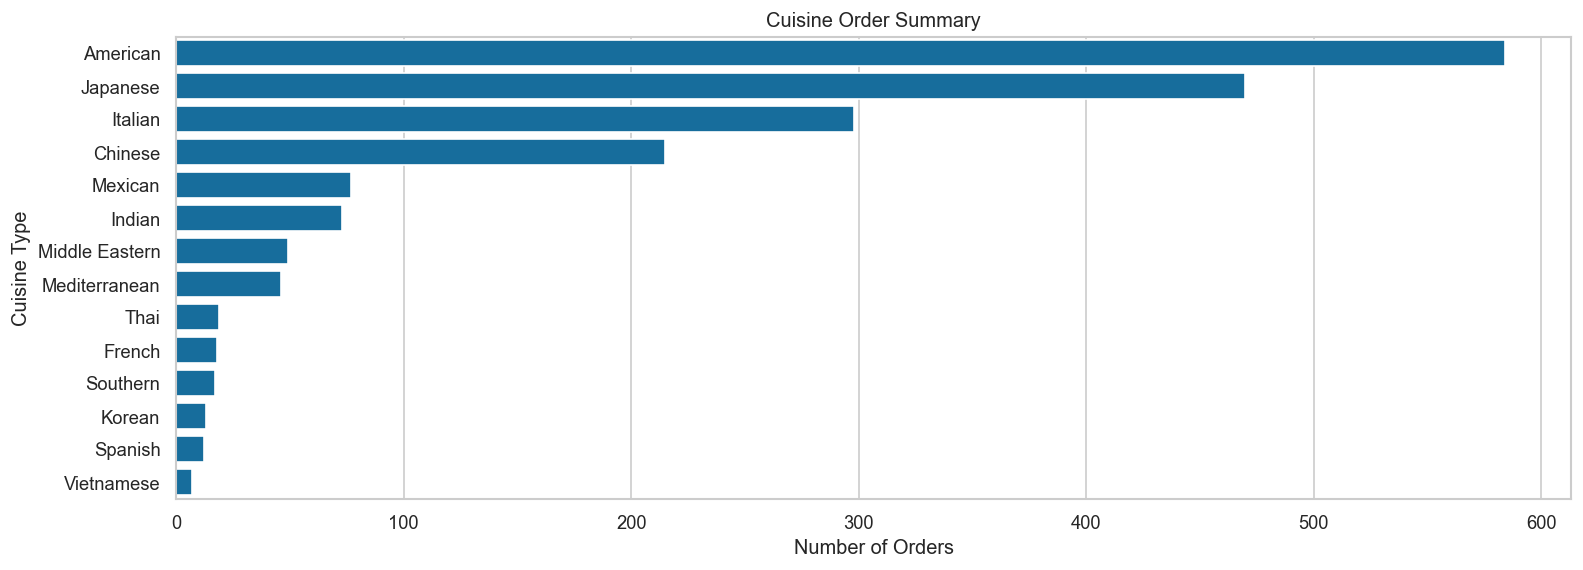

In [248]:
# Countplot sorted by the order frequency of each cuisine type starting with the
# highest to the lowest.

plt.figure(figsize=(15, 5))

sns.countplot(data=df, y='cuisine_type',
              order=df['cuisine_type'].value_counts().index)

plt.title('Cuisine Order Summary')
plt.xlabel('Number of Orders')
plt.ylabel('Cuisine Type')
plt.show()

#### Observations

The dataset contains **14 unique cuisine types**. The distribution 
is heavily skewed towards **American** and **Japanese** cuisine, 
accounting for the majority of all orders. 

On the lower end, cuisines such as Vietnamese, Spanish, and Korean 
have very few orders, suggesting either low demand or limited 
restaurant availability on the platform.

This concentration in a small number of cuisine types is worth 
reviewing for further analysis.

---

#### Order Cost (cost_of_the_order)

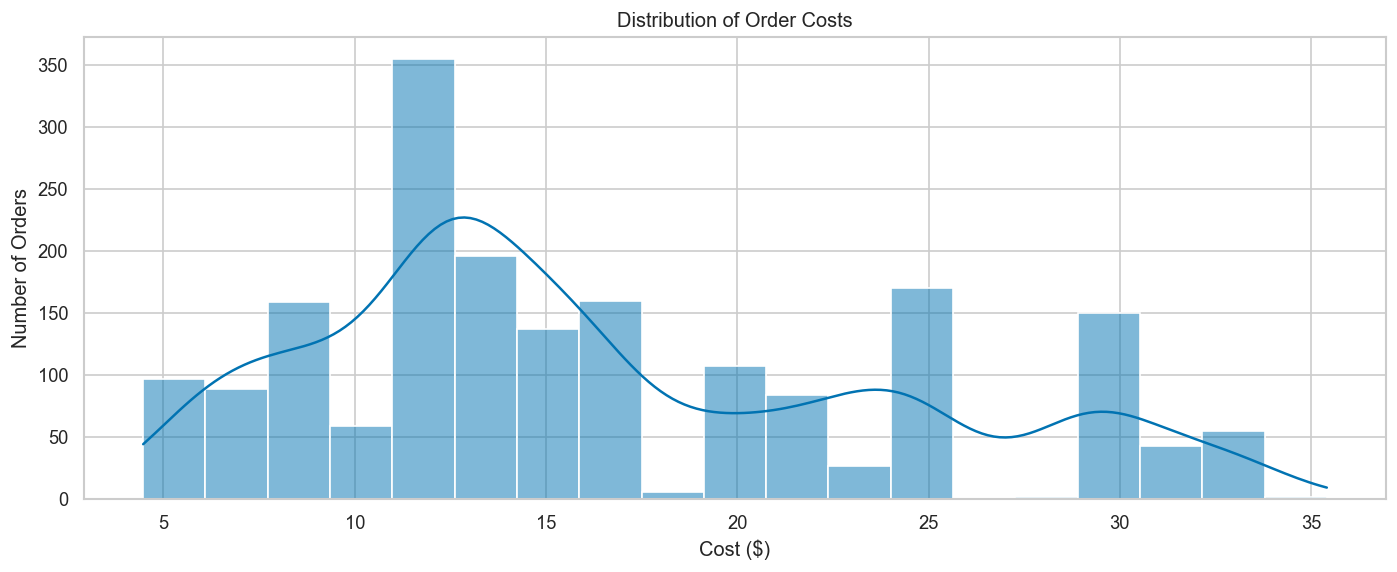

In [249]:
# Histogram with KDE (Kernel Density Estimate) to show the distribution of order costs

plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='cost_of_the_order', kde=True)
plt.title('Distribution of Order Costs')
plt.xlabel('Cost ($)')
plt.ylabel('Number of Orders')
plt.show()


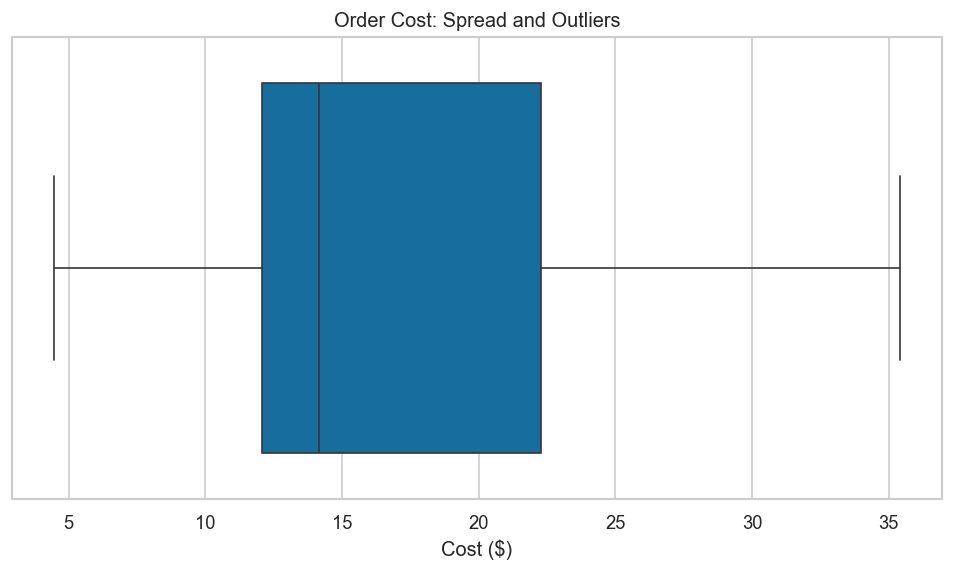

In [250]:
# Boxplot to show summary statistics and potential outliers in order costs

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cost_of_the_order')
plt.title('Order Cost: Spread and Outliers')
plt.xlabel('Cost ($)')
plt.show()

#### Observations

**Histogram:** The cost distribution is **right-skewed**, the majority 
of orders fall in the **$10–$20 range**, but there is a tail of higher-value 
orders, which pulls the mean ($16.49) above the median ($14.14). This was 
first noted in Question 4.

**Boxplot:** Confirms the skew with the median line sitting left of 
center in the box. A small number of orders at the higher end approach 
the $35 maximum but do not appear as extreme outliers beyond the whiskers.

---

#### Week Day (day_of_the_week)

In [251]:
# Count the unique day types and their order frequency
print(f'There are {df["day_of_the_week"].nunique()} Unique day types in the dataset.')
print()
print(df['day_of_the_week'].value_counts())

There are 2 Unique day types in the dataset.

day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64


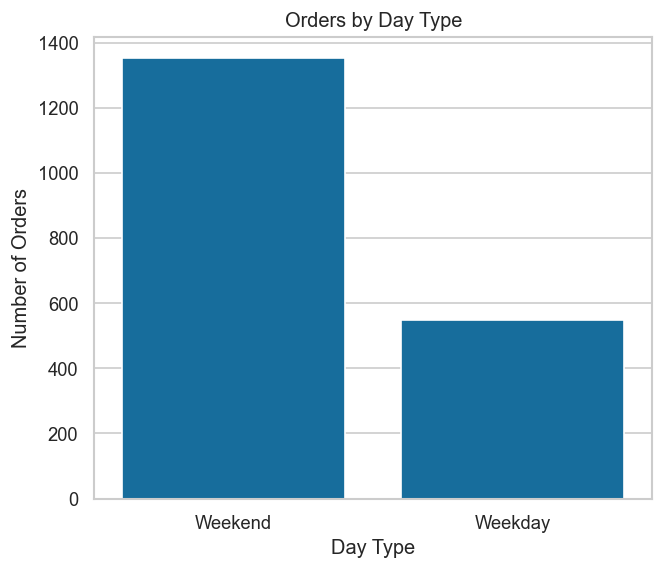

In [252]:
# day_of_the_week is a categorical variable with two values: Weekday and Weekend.
# Countplot is a good way to visualize the number of orders between the two

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='day_of_the_week',
            order=df['day_of_the_week'].value_counts().index)
plt.title('Orders by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Number of Orders')
plt.show()

#### Observations

There are **2 unique day types**, Weekday and Weekend. The countplot 
shows a clear imbalance, with weekend orders significantly 
outnumbering weekday orders.

The impact of this distribution on delivery time and cost will be 
explored further in the multivariate and business analysis sections.

---

#### Rating (rating)

In [253]:
# Count the unique ratings and their frequency
# Note that we are still looking at the original 'rating' column which contains the text values.

print(f'There are {df["rating"].nunique()} Unique rating values in the dataset.')
print()
print(df['rating'].value_counts())


There are 4 Unique rating values in the dataset.

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64


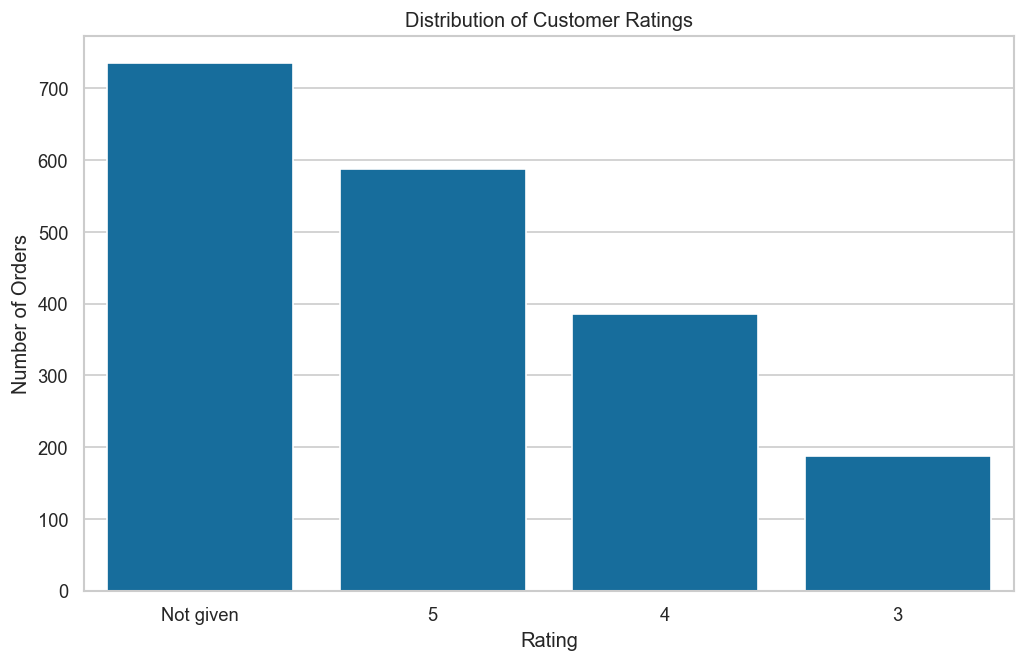

In [254]:
# Countplot to visualize the frequency of each rating value. 
# Original rating column is used so original values are shown.

sns.countplot(x='rating', data=df,
            order=df['rating'].value_counts().index)
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

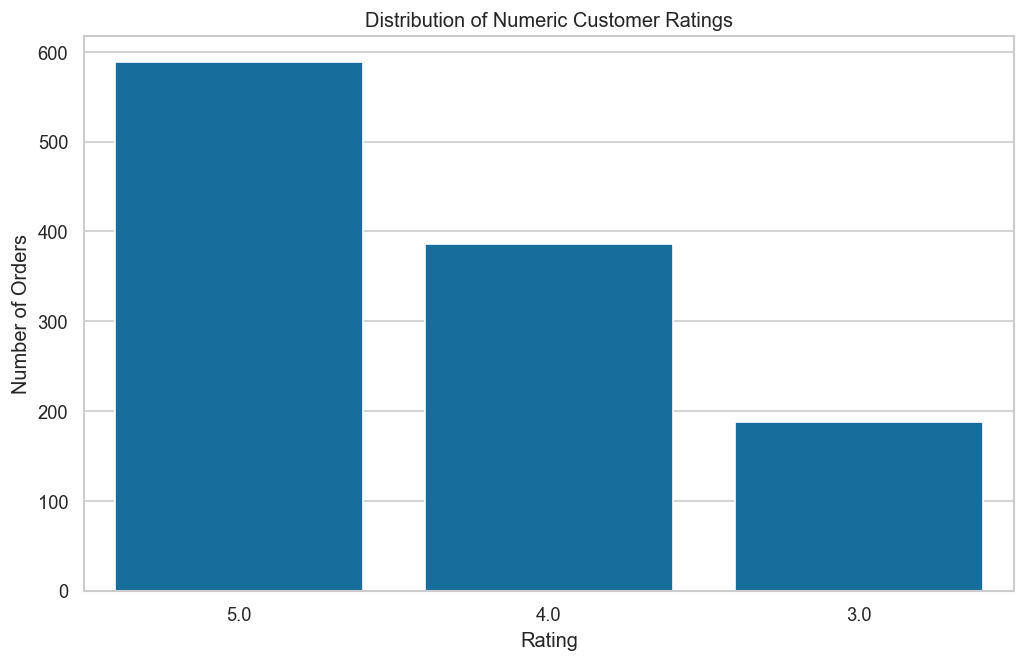

In [255]:
# rating_numeric column is used to show only the numeric values.

sns.countplot(x='rating_numeric', data=df,
            order=df['rating_numeric'].value_counts().index)
plt.title('Distribution of Numeric Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

#### Observations

The **rating** column contains **4 unique values**: numeric ratings 
of **3**, **4**, and **5**, and the text value **Not given** for unrated orders.

As addressed in **Question 5**, the **Not given** entries were converted 
to **NaN** in the **rating_numeric** column to enable numeric analysis on ratings going forward. 
The original rating column is preserved for categorical analysis such as this chart.

The dataset does not include any ratings of 1 or 2. This may 
suggest customers who rated their experience were largely satisfied.

---

#### Food Preparation Time (food_preparation_time)

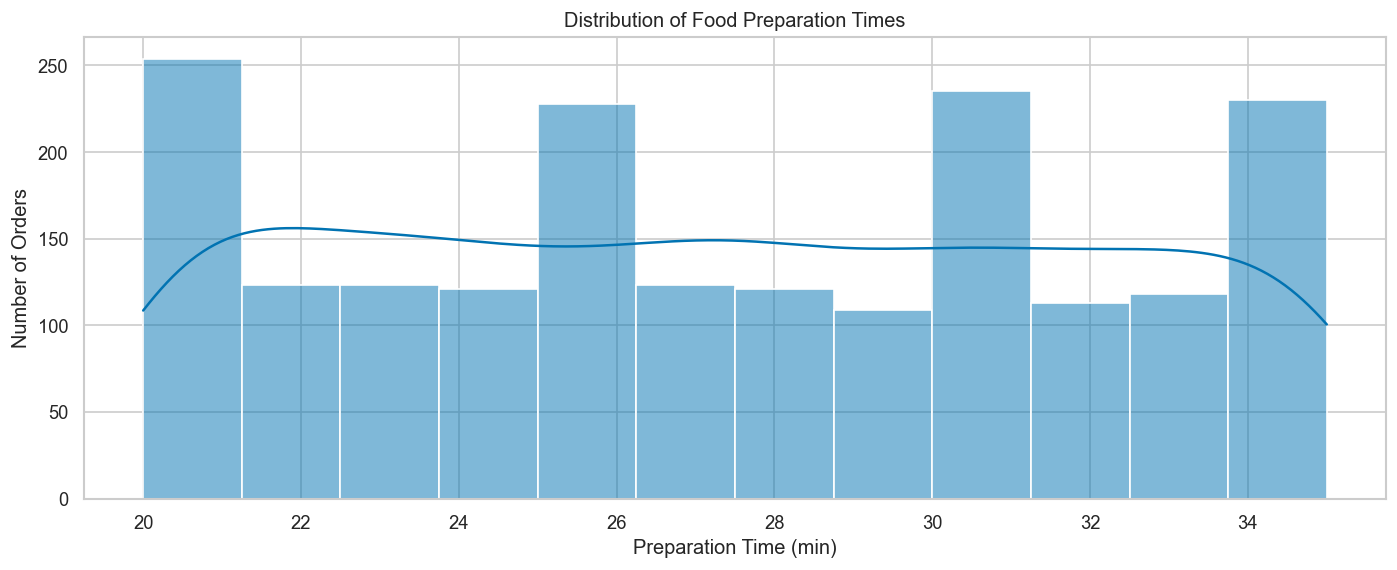

In [256]:
# Histogram with KDE (Kernel Density Estimate) to show the distribution of food preparation times

plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='food_preparation_time', kde=True)
plt.title('Distribution of Food Preparation Times')
plt.xlabel('Preparation Time (min)')
plt.ylabel('Number of Orders')
plt.show()

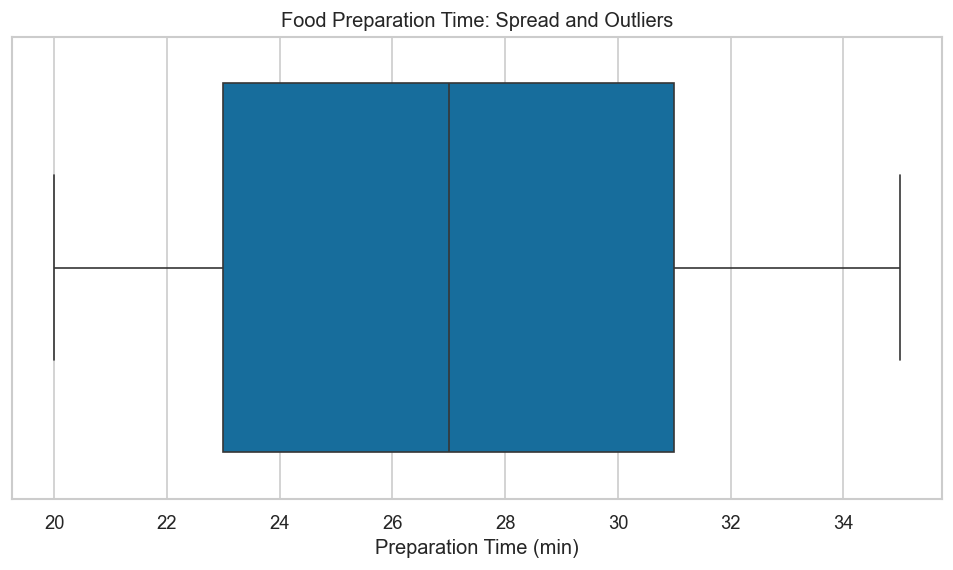

In [257]:

# Boxplot to show summary statistics and potential outliers in food preparation times

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='food_preparation_time')
plt.title('Food Preparation Time: Spread and Outliers')
plt.xlabel('Preparation Time (min)')
plt.show()

#### Observations

Food preparation time ranges from **20 to 35 minutes** across 
all orders. Unlike order cost, the distribution is **roughly 
symmetric**, the mean at (27.37 min) and median (27 min) are nearly 
identical, and the boxplot shows no significant outliers.

The narrow 15-minute range suggests preparation times are fairly 
consistent across restaurants, with no extreme cases pulling the 
average in either direction.

---

#### Delivery Time (delivery_time)

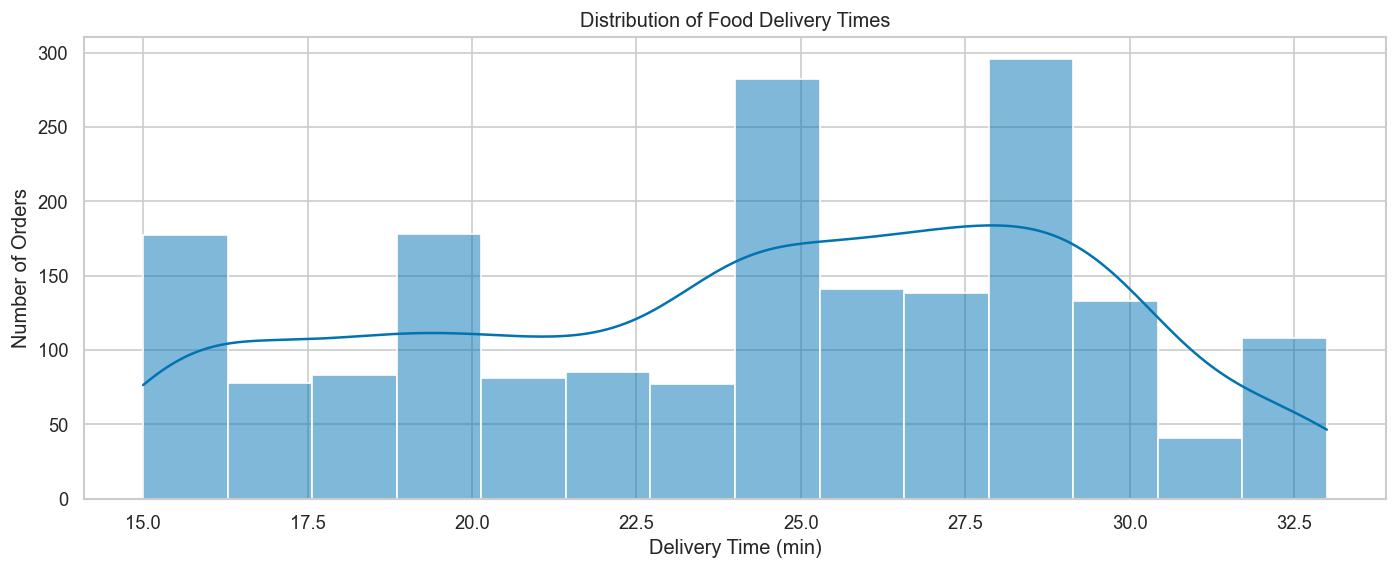

In [258]:
# Histogram with KDE (Kernel Density Estimate) to show the distribution of food delivery times

plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='delivery_time', kde=True)
plt.title('Distribution of Food Delivery Times')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Number of Orders')
plt.show()

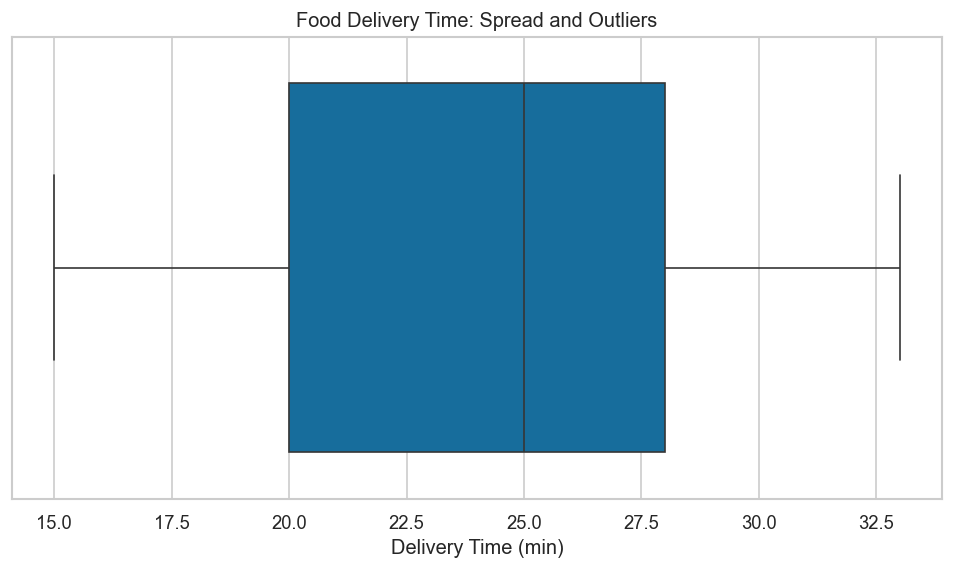

In [259]:
# Boxplot to show summary statistics and potential outliers in food delivery times

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='delivery_time')
plt.title('Food Delivery Time: Spread and Outliers')
plt.xlabel('Delivery Time (min)')
plt.show()

#### Observations

Delivery time ranges from **15 to 33 minutes** across all orders. 
Similar to food preparation time, the distribution is **roughly 
symmetric** with the mean (24.16 min) and median (25 min) closely 
aligned and no significant outliers.

Combined with the preparation time analysis, the average total 
wait from order placement to delivery is approximately **51 minutes**,
a metric that will be examined further in the business analysis.

---

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [260]:
# Create a new dataframe with the top 5 restaurants.

top_5_restaurants = df['restaurant_name'].value_counts().head(5)
print(top_5_restaurants)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


In [261]:
# normalize=True to get the normalized count of orders and multiplying by 100 to get a percentage.

top_restaurants = df['restaurant_name'].value_counts(normalize=True).head(5) * 100
print(top_restaurants.round(2))

restaurant_name
Shake Shack                 11.5400
The Meatball Shop            6.9500
Blue Ribbon Sushi            6.2700
Blue Ribbon Fried Chicken    5.0600
Parm                         3.5800
Name: proportion, dtype: float64


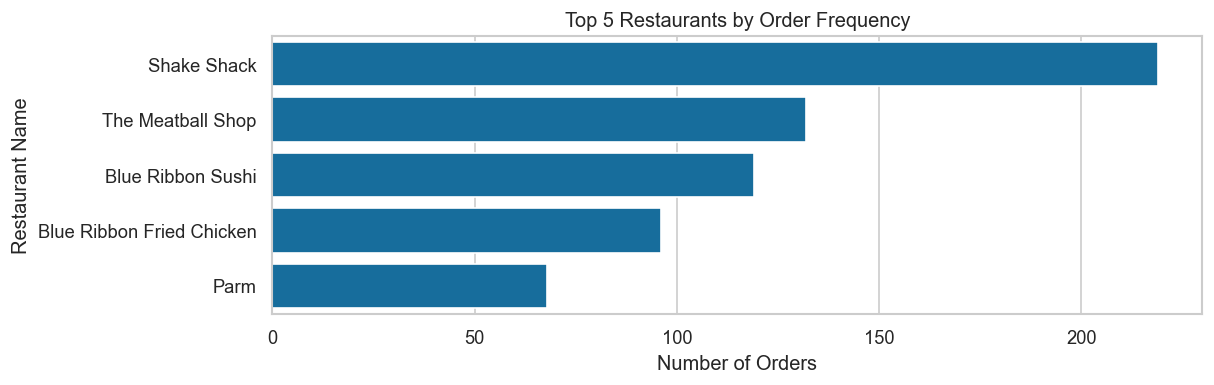

In [262]:
# Countplot to show the number of orders for each restaurant.
# order=df to sort their order frequency, starting with the highest to the lowest.

plt.figure(figsize=(10, 3))
sns.countplot(data=df,
            y='restaurant_name',
            order=df['restaurant_name'].value_counts().head(5).index)

plt.title('Top 5 Restaurants by Order Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.show()

#### Observations
The top 5 restaurants based on the total number of orders are: 
- Shake Shack (219 orders - 12%)
- The Meatball Shop (132 orders - 7%)
- Blue Ribbon Sushi (119 orders - 6%)
- Blue Ribbon Fried Chicken (96 orders - 5%)
- Parm (68 orders - 4%)

The top 5 restaurants account for roughly 34% of all orders

---

### **Question 8**: Which is the most popular cuisine on weekends?

In [263]:
# Create a filtered DataFrame that only contains weekend orders
weekend_df = df[df['day_of_the_week'] == 'Weekend']

# count the orders by cuisine type on weekends to view which cuisines are most popular.
print(weekend_df['cuisine_type'].value_counts())
print()


cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64



In [264]:
# normalize=True to get the normalized count of cuisine type and multiplying by 100 to get a percentage.

top_cuisine = weekend_df['cuisine_type'].value_counts(normalize=True) * 100
print(top_cuisine.round(2))

cuisine_type
American         30.7200
Japanese         24.8000
Italian          15.3200
Chinese          12.0700
Mexican           3.9200
Indian            3.6300
Mediterranean     2.3700
Middle Eastern    2.3700
Thai              1.1100
French            0.9600
Korean            0.8100
Southern          0.8100
Spanish           0.8100
Vietnamese        0.3000
Name: proportion, dtype: float64


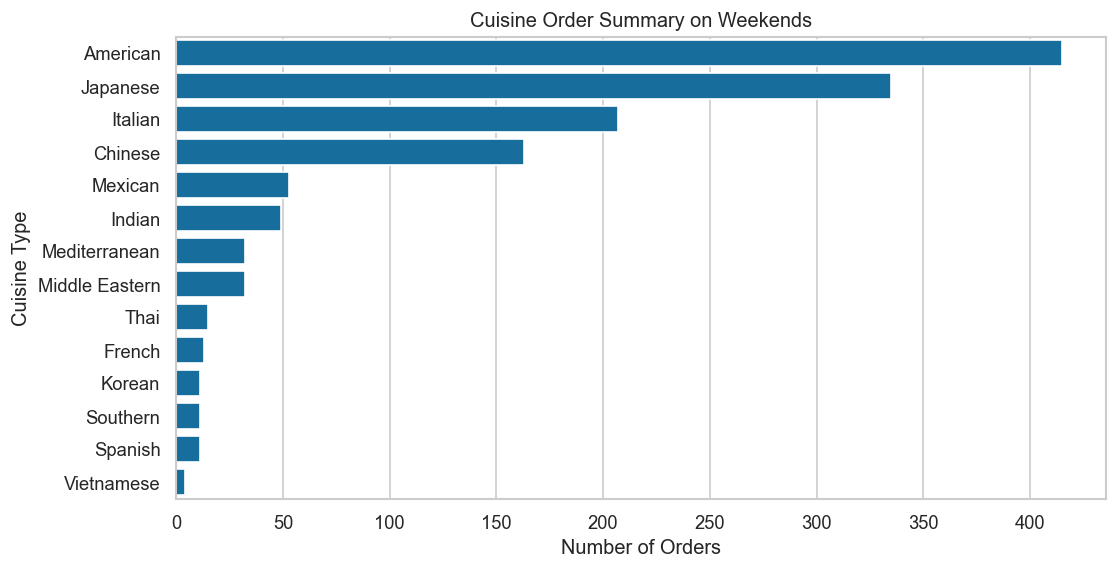

In [265]:
# countplot to show the number of orders for each cuisine type on weekends.
# order=df to sort their order frequency, starting with the highest to the lowest.

plt.figure(figsize=(10, 5))
sns.countplot(data=weekend_df,
            y='cuisine_type',
            order=weekend_df['cuisine_type'].value_counts().index
)
plt.title('Cuisine Order Summary on Weekends')
plt.ylabel('Cuisine Type')
plt.xlabel('Number of Orders')
plt.show()

#### Observations

On weekends, **American** cuisine leads in order volume followed 
closely by **Japanese**. This mirrors the overall dataset pattern 
from Question 6, suggesting cuisine preference is consistent 
regardless of the day.

The percentage breakdown shows the top 4 cuisines account for roughly **83%** of all weekend orders, with the remaining 
cuisine types each representing a small fraction of demand.

---


### **Question 9**: What percentage of the orders cost more than 20 dollars?

The number of orders that cost more than 20 dollars is 555.
The % of orders that cost more than 20 dollars is 29.24%.

The number of orders that cost 20 dollars or less is 1343.
The % of orders that cost 20 dollars or less is 70.76%.


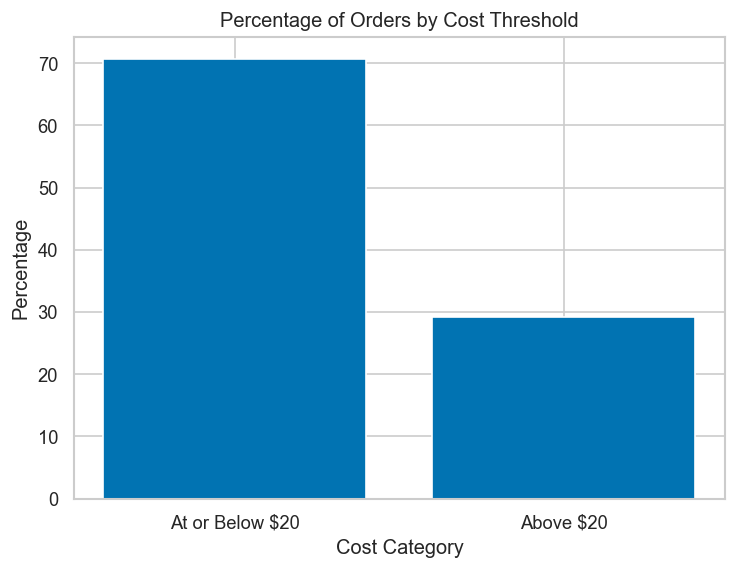

In [266]:
# Create separate variables for the two order groups.
# Calculate the percentage for each group by dividing by the total number of orders and multiplying by 100.

above_20 = df[df['cost_of_the_order'] > 20]
below_20 = df[df['cost_of_the_order'] <= 20]
pct_greater_20 = (len(above_20) / len(df)) * 100
pct_below_20 = (len(below_20) / len(df)) * 100

print(f"The number of orders that cost more than 20 dollars is {len(above_20)}.")
print(f"The % of orders that cost more than 20 dollars is {pct_greater_20:.2f}%.")
print()
print(f"The number of orders that cost 20 dollars or less is {len(below_20)}.")
print(f"The % of orders that cost 20 dollars or less is {pct_below_20:.2f}%.")

# Since we are interested in % of orders greater than $20 we can visualize the data.
# We can use a bar chart to show the % of orders above and below 20 dollars.

categories = ['At or Below $20','Above $20']
percentages = [pct_below_20, pct_greater_20]

plt.figure(figsize=(7, 5))
plt.bar(categories, percentages)
plt.title('Percentage of Orders by Cost Threshold')
plt.xlabel('Cost Category')
plt.ylabel('Percentage')
plt.show()


#### Observations:
Approximately **29%** of orders exceed $20 while **71%** fall at 
or below that threshold. The majority of orders are in the 
lower cost range, consistent with the right-skewed distribution 
observed in Question 6.

---

### **Question 10**: What is the mean order delivery time?

In [267]:
# .mean() to calculate the mean order delivery time.

mean_delivery_time = df['delivery_time'].mean()
print(f"The mean delivery time is {mean_delivery_time:.2f} minutes.")


The mean delivery time is 24.16 minutes.


#### Observations

The mean or average order delivery time across all orders in the data set is just over **24 minutes**

- This was first identified in Question 4 when we used the **.describe()** to get summary statistics across the dataset.
- The distribution was visualized in Question 6 through a histogram and boxplot, which confirmed delivery times are consistent
with no significant outliers.

---

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.

In [268]:
# Create variables for the top 3 customers to provide a 20% discount voucher.
# .value_counts() to count the number of orders by 'customer_id'
# .head(3) to get the 3 customers with the most orders.

top_customers = df['customer_id'].value_counts().head(3)

print("The top 3 customers to provide a 20% discount voucher are:")
print()

for customer_id, order_count in top_customers.items():
    print(f"Customer ID: {customer_id}, Number of Orders: {order_count}")

The top 3 customers to provide a 20% discount voucher are:

Customer ID: 52832, Number of Orders: 13
Customer ID: 47440, Number of Orders: 10
Customer ID: 83287, Number of Orders: 9


#### Observations

The top 3 customers by order volume are eligible for a 20% discount 
voucher. These customers represent FoodHub's most loyal users.

While 32 orders out of 1,898 may not seem like a lot, 
providing a discount program and rewarding higher-frequency customers could support
long-term retention and expand to a broader set of customers.

---

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)


#### Cuisine Analysis

**Cuisine Type vs Cost of Order**

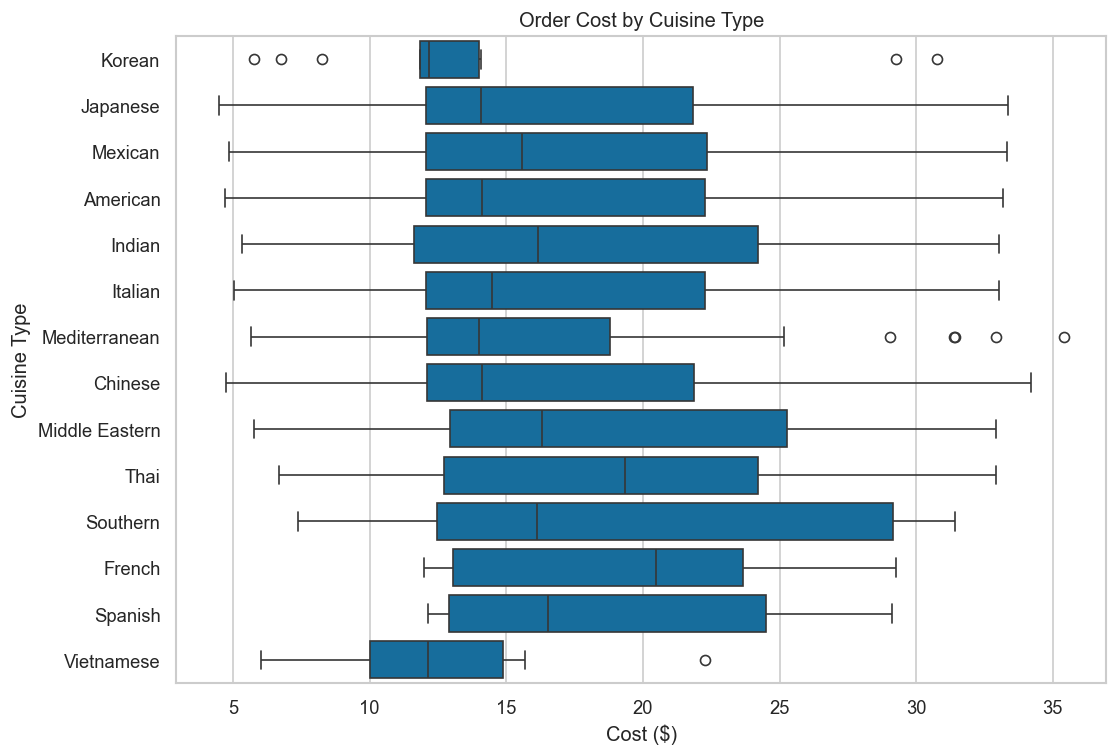

In [269]:
# Boxplot showing the distribution of order cost across cuisine types

plt.figure(figsize=(10, 7))

sns.boxplot(data=df,
            x='cost_of_the_order',
            y='cuisine_type',
            order=df['cuisine_type'])

plt.title('Order Cost by Cuisine Type')
plt.xlabel('Cost ($)')
plt.ylabel('Cuisine Type')
plt.show()

#### Observations

Order cost varies across cuisine types with a notable spread 
from top to bottom.

- **French** and **Thai** cuisines have the highest median order 
  costs, while **Korean** and **Vietnamese** have the lowest.
- 6 cuisine types sit above the overall dataset median of $14.14, 
  while 7 fall below it.
- **Mediterranean** shows the most high-end outliers, suggesting 
  occasional very high-value orders within that cuisine.
- **Korean** shows the most low-end outliers, indicating some 
  unusually low-cost orders pulling below the typical range.

**Distribution Shape**

- **French** and **Thai** are **right-skewed**: their mean exceeds 
  their median, indicating a tail of higher-value orders pulling 
  the average up.
- All remaining cuisine types are **left-skewed**: their median 
  exceeds their mean, with orders clustering toward the upper 
  portion of their range.

---

**Cuisine Type vs Food Preparation Time**

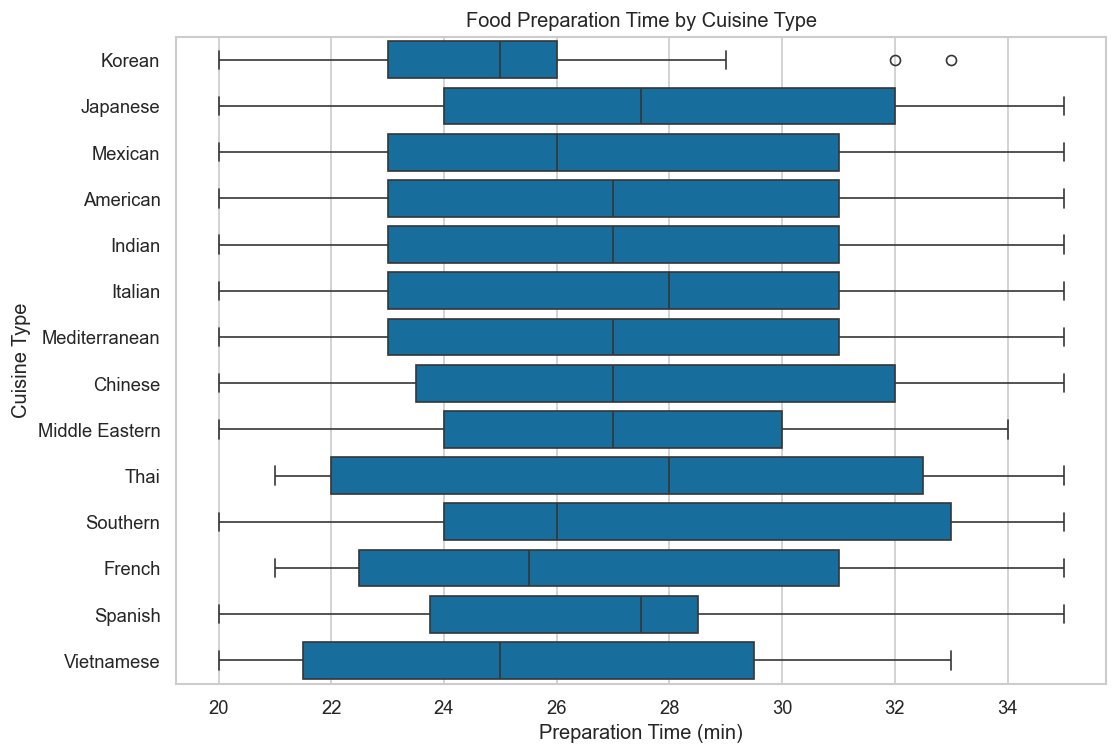

In [270]:
# Boxplot showing the distribution of food preparation time across cuisine types

plt.figure(figsize=(10, 7))

sns.boxplot(data=df,
            x='food_preparation_time',
            y='cuisine_type',
            order=df['cuisine_type'])

plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Preparation Time (min)')
plt.ylabel('Cuisine Type')
plt.show()

In [271]:
# Calculate IQR per cuisine type for food preparation time
# IQR = Q3 (75th percentile) - Q1 (25th percentile)

cuisine_prep_iqr = (
    df.groupby('cuisine_type')['food_preparation_time'].quantile(0.75) -
    df.groupby('cuisine_type')['food_preparation_time'].quantile(0.25)
).sort_values(ascending=False)

print('Food Preparation Time IQR by Cuisine:')
print()

for cuisine, iqr in cuisine_prep_iqr.items():
    print(f'  • {cuisine}: {iqr:.1f} minutes')

Food Preparation Time IQR by Cuisine:

  • Thai: 10.5 minutes
  • Southern: 9.0 minutes
  • Chinese: 8.5 minutes
  • French: 8.5 minutes
  • American: 8.0 minutes
  • Indian: 8.0 minutes
  • Italian: 8.0 minutes
  • Japanese: 8.0 minutes
  • Mediterranean: 8.0 minutes
  • Mexican: 8.0 minutes
  • Vietnamese: 8.0 minutes
  • Middle Eastern: 6.0 minutes
  • Spanish: 4.8 minutes
  • Korean: 3.0 minutes


#### Observations

- **Korean** has the shortest median preparation time.
- **Korean** is the only cuisine with outliers, both at the 
  higher end (32 and 33 minutes), which exceed Korean's 
  own upper whisker of 29 minutes but remain within the 
  overall dataset range.

- **Thai** has the widest IQR (10.5 minutes, ranging from 
  approximately 22 to 32.5 minutes), indicating that Thai 
  restaurant preparation times are the most variable 
- **Thai** cuisine can take anywhere from a quick turnaround 
  to near the maximum range.

**Distribution Shape**

- 6 cuisine types are right-skewed and 5 are left-skewed, 
  a more balanced split than the cost distribution.

**IQR Analysis**
- The IQR analysis confirms that **Korean** cuisine has the most 
consistent preparation times, the middle 50% of orders are 
prepared within a 3 minute window. In contrast, **Thai** cuisine 
has the widest spread at 10.5 minutes, meaning preparation time 
is far less predictable.

Most other cuisines fall in the 8–9 minute IQR range, suggesting 
moderate variability across the platform.

---

#### Day of Week Analysis

**Day of Week vs Delivery TIme**

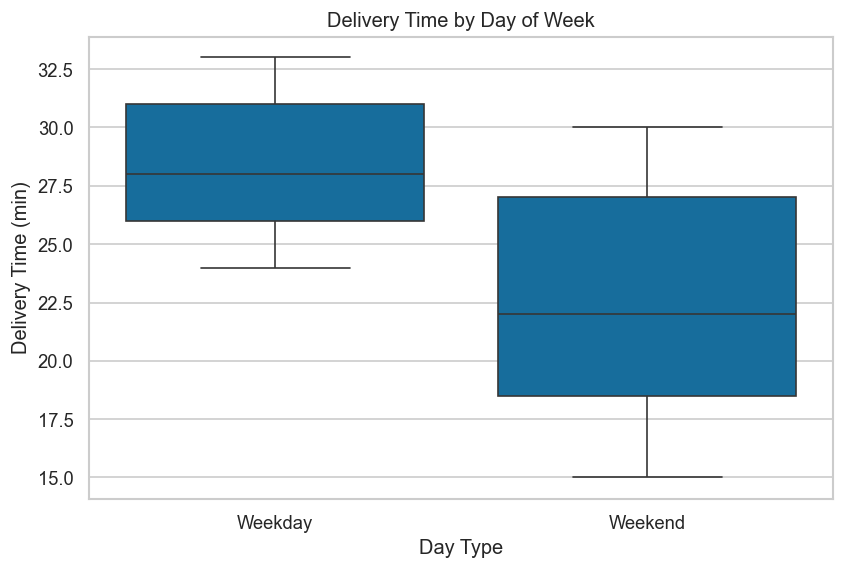

In [272]:
# Boxplot comparing delivery time between weekdays and weekends

plt.figure(figsize=(8, 5))

sns.boxplot(data=df,
            x='day_of_the_week',
            y='delivery_time',
            order=['Weekday', 'Weekend'])

plt.title('Delivery Time by Day of Week')
plt.xlabel('Day Type')
plt.ylabel('Delivery Time (min)')
plt.show()

In [273]:
# Analytical summary: mean, median and IQR per day type
day_stats = df.groupby('day_of_the_week')['delivery_time'].agg(['mean', 'median'])
day_iqr = (
    df.groupby('day_of_the_week')['delivery_time'].quantile(0.75) -
    df.groupby('day_of_the_week')['delivery_time'].quantile(0.25)
)

day_stats['IQR'] = day_iqr

print(day_stats)

                   mean  median    IQR
day_of_the_week                       
Weekday         28.3400 28.0000 5.0000
Weekend         22.4700 22.0000 8.5000


#### Observations

Delivery time differs between weekdays and weekends in both 
speed and consistency.

**Weekday**
- Range approximately 24–33 minutes with a median of 28 minutes
- IQR of 5 minutes means a tight and predictable delivery window

**Weekend**
- Range approximately 15–30 minutes with a lower median
- IQR of 8.5 minutes means a wider and less predictable delivery window

Both distributions are roughly symmetric with mean and median 
closely aligned. No outliers appear on either day type.

**Notable Finding**

Delivery is faster on weekends despite weekends accounting for 
71.2% of all orders. This is an unexpected, higher demand 
would typically suggest slower delivery. A deeper investigation 
into driver staffing and routing on weekends would be needed 
to understand this pattern, which is beyond the scope of 
this initial analysis.

Weekday delivery is more **consistent** (IQR 5 min) while 
weekend delivery has more **variability** (IQR 8.5 min).

---

#### Rating Analysis

**Rating vs Delivery Time**

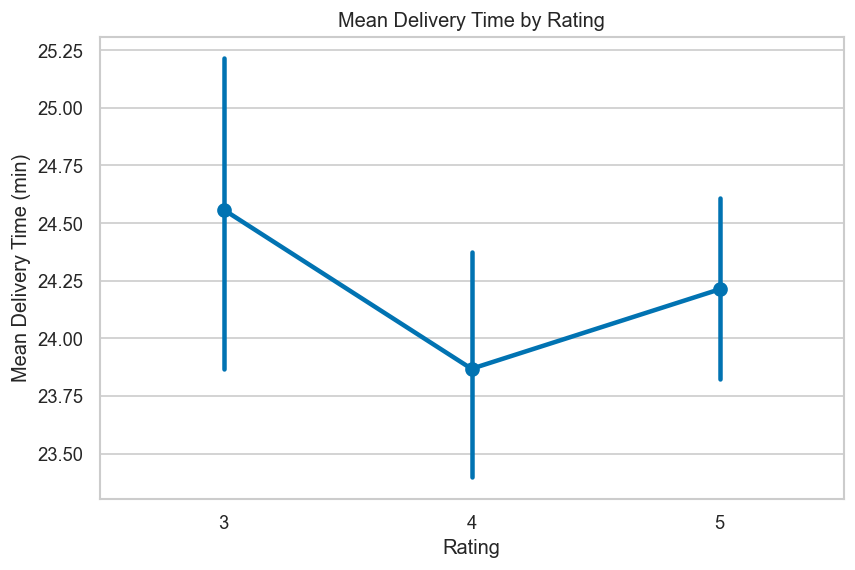

In [274]:
# Filter to rated orders only: exclude 'Not given'

rated_df = df[df['rating'] != 'Not given'].copy()

# Pointplot to show mean delivery time per rating level
# Note: the compressed y-axis scale can make small differences 
# appear more significant than they actually are

plt.figure(figsize=(8, 5))

sns.pointplot(data=rated_df,
              x='rating',
              y='delivery_time',
              order=['3', '4', '5'])

plt.title('Mean Delivery Time by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Delivery Time (min)')
plt.show()

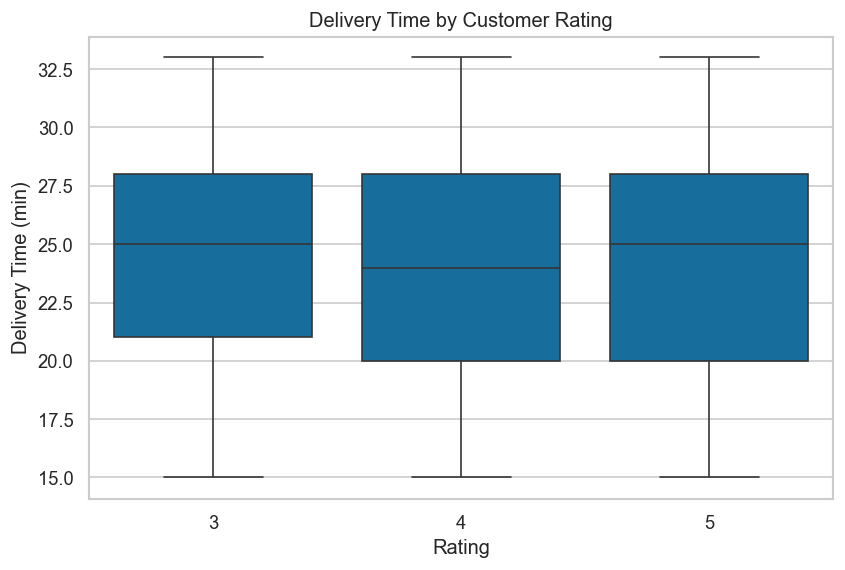

In [275]:
# Filter to rated orders only: exclude 'Not given'
rated_df = df[df['rating'] != 'Not given'].copy()

# Boxplot provides full distributional context
# When viewed against the complete range, the differences 
# between rating groups seen in the point plot are negligible
plt.figure(figsize=(8, 5))

sns.boxplot(data=rated_df,
            x='rating',
            y='delivery_time',
            order=['3', '4', '5'])

plt.title('Delivery Time by Customer Rating')
plt.xlabel('Rating')
plt.ylabel('Delivery Time (min)')
plt.show()

In [276]:
# Analytical summary: mean, median and IQR per rating level
rating_stats = rated_df.groupby('rating')['delivery_time'].agg(['mean', 'median'])
rating_iqr = (
    rated_df.groupby('rating')['delivery_time'].quantile(0.75) -
    rated_df.groupby('rating')['delivery_time'].quantile(0.25)
)

rating_stats['IQR'] = rating_iqr
print(rating_stats)

          mean  median    IQR
rating                       
3      24.5585 25.0000 7.0000
4      23.8679 24.0000 8.0000
5      24.2126 25.0000 8.0000


#### Observations

At first glance, delivery time does not appear to be a significant 
driver of customer ratings.

- All three rating levels fall within the same **15–33 minute** 
  overall range
- Median delivery time is nearly identical across ratings; 
  **25 minutes** for ratings 3 and 5, and **24 minutes** for rating 4
- IQR is consistent across all ratings; **7 minutes** for rating 3 
  and **8 minutes** for both ratings 4 and 5
- Ratings 3 and 5 show a slight **left skew** while rating 4 
  is approximately **symmetric**, though all three have mean 
  and median closely aligned

**Key Finding**

The near-identical distributions across all rating levels suggest 
that delivery time alone does not meaningfully influence how 
customers rate their experience. Other factors such as food 
quality, preparation time, or order accuracy may play a 
larger role, which will be explored in the following sections.

**Note:** 736 orders (38.8%) with no rating were excluded from 
this analysis. It is possible that the unrated segment contains 
orders with longer delivery times, which could influence 
the overall picture if ratings were available.

**Note on Scale for Delivery Time**

The point plot above shows a subtle V-shape, ratings 3 and 5 
appear to have slightly higher mean delivery times (24.5 and 
24.25 minutes) while rating 4 dips to 23.9 minutes. Viewed 
in isolation this pattern might suggest that a 4-star experience 
correlates with faster delivery.

However the y-axis spans less than 1 minute of difference. 
The actual delivery time range across the full dataset is 
15–33 minutes. The boxplot below shows that when placed in 
that full context, the V-shape disappears as a meaningful signal.

---

**Rating vs Food Prepartion Time**

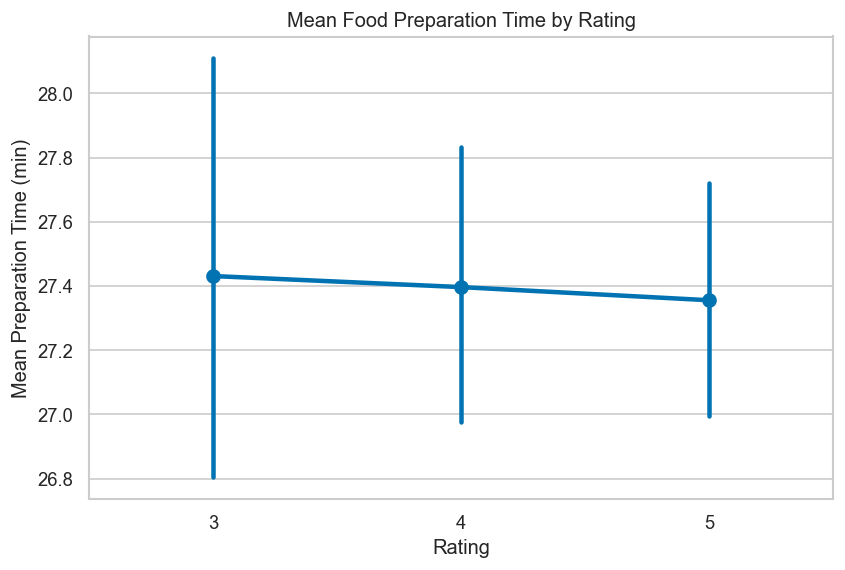

In [277]:
# Pointplot to show mean delivery time per rating level
# Note: the compressed y-axis scale can make small differences 
# appear more significant than they actually are

plt.figure(figsize=(8, 5))

sns.pointplot(data=rated_df,
              x='rating',
              y='food_preparation_time',
              order=['3', '4', '5'])

plt.title('Mean Food Preparation Time by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Preparation Time (min)')
plt.show()

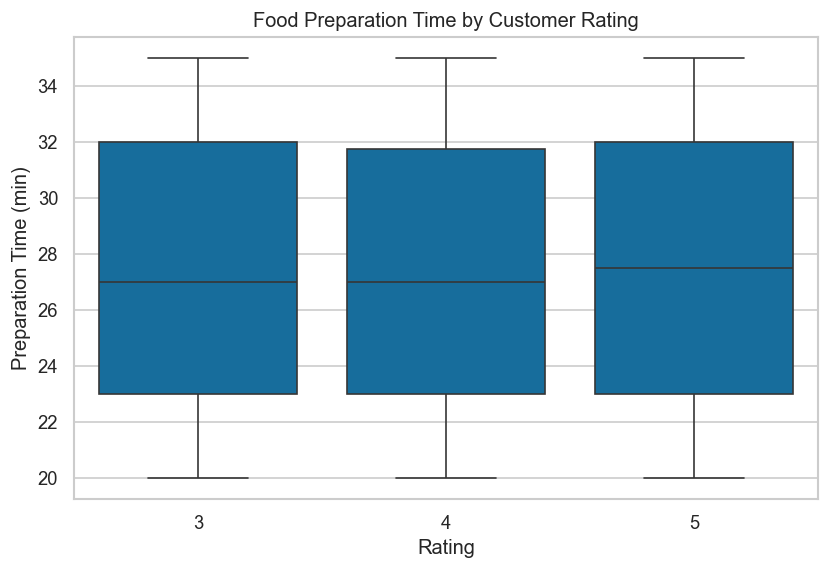

In [278]:
# Boxplot provides full distributional context
# When viewed against the complete range, the differences 
# between rating groups seen in the point plot are negligible

plt.figure(figsize=(8, 5))

sns.boxplot(data=rated_df,
            x='rating',
            y='food_preparation_time',
            order=['3', '4', '5'])

plt.title('Food Preparation Time by Customer Rating')
plt.xlabel('Rating')
plt.ylabel('Preparation Time (min)')
plt.show()

In [279]:
# Analytical summary: mean, median and IQR per rating level
rating_prep_stats = rated_df.groupby('rating')['food_preparation_time'].agg(['mean', 'median'])
rating_prep_iqr = (
    rated_df.groupby('rating')['food_preparation_time'].quantile(0.75) -
    rated_df.groupby('rating')['food_preparation_time'].quantile(0.25)
)

rating_prep_stats['IQR'] = rating_prep_iqr
print(rating_prep_stats)

          mean  median    IQR
rating                       
3      27.4309 27.0000 9.0000
4      27.3964 27.0000 8.7500
5      27.3554 27.5000 9.0000


#### Observations

Food preparation time shows no meaningful relationship with 
customer ratings, similar to the findings from delivery time.

- All three rating levels span the same **20–35 minute** range 
  with no outliers
- Median prep time is virtually identical, **27 minutes** for 
  ratings 3 and 4, and **27.5 minutes** for rating 5
- IQR is consistent across all ratings, **9 minutes** for 
  ratings 3 and 5, and **8.75 minutes** for rating 4
- Ratings 3 and 4 show a slight **left skew** while rating 5 
  is approximately **symmetric**

**Key Finding**

Neither delivery time nor food preparation time appear to 
significantly influence customer ratings. This raises an 
important question, if operational timing is not the driver, 
what is? The relationship between cost and rating will be 
explored in the next Question

**Note on the Scale of Food Preparation Time**

The point plot above shows a gentle declining line from rating 3 
to rating 5, which could suggest that shorter preparation times 
lead to higher ratings, a logical and tempting conclusion.

However the y-axis spans less than 1 minute across all three 
rating levels. The actual preparation time range is 20–35 minutes. 
The boxplot below reveals that the declining trend is negligible 
relative to the full distribution, and no meaningful step pattern 
exists across rating levels.

---

**Rating vs Cost of Order**

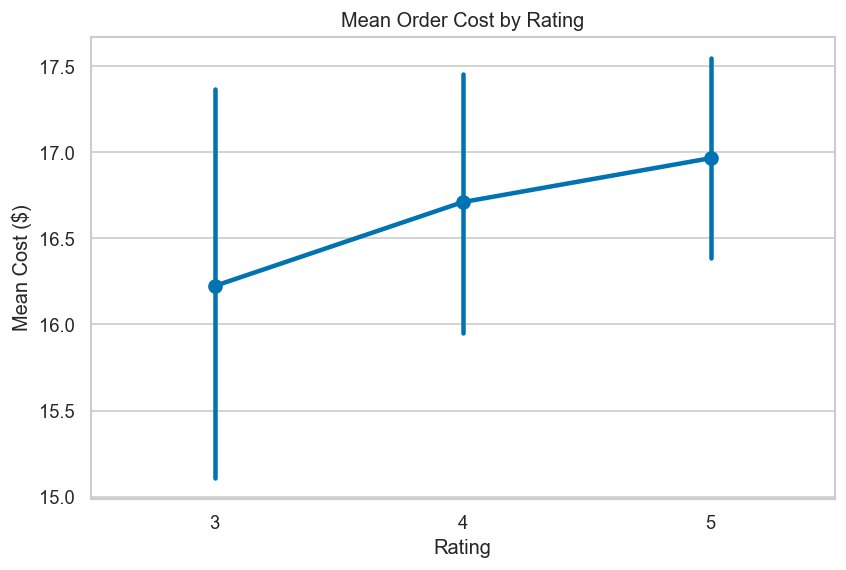

In [280]:
# Pointplot to show mean delivery time per rating level
# Note: the compressed y-axis scale can make small differences 
# appear more significant than they actually are

plt.figure(figsize=(8, 5))

sns.pointplot(data=rated_df,
              x='rating',
              y='cost_of_the_order',
              order=['3', '4', '5'])

plt.title('Mean Order Cost by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Cost ($)')
plt.show()

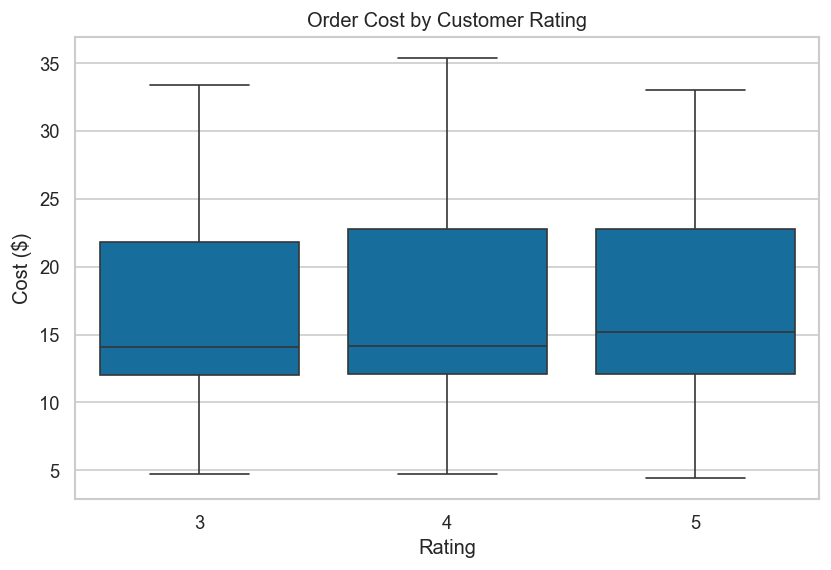

In [281]:
# Boxplot provides full distributional context
# When viewed against the complete range, the differences 
# between rating groups seen in the point plot are negligible

plt.figure(figsize=(8, 5))

sns.boxplot(data=rated_df,
            x='rating',
            y='cost_of_the_order',
            order=['3', '4', '5'])

plt.title('Order Cost by Customer Rating')
plt.xlabel('Rating')
plt.ylabel('Cost ($)')
plt.show()

In [282]:
# Analytical summary: mean, median and IQR per rating level
rating_cost_stats = rated_df.groupby('rating')['cost_of_the_order'].agg(['mean', 'median'])
rating_cost_iqr = (
    rated_df.groupby('rating')['cost_of_the_order'].quantile(0.75) -
    rated_df.groupby('rating')['cost_of_the_order'].quantile(0.25)
)

rating_cost_stats['IQR'] = rating_cost_iqr
print(rating_cost_stats)

          mean  median     IQR
rating                        
3      16.2234 14.1200  9.7875
4      16.7103 14.1600 10.6575
5      16.9657 15.2050 10.6700


#### Observations

Order cost shows slightly more variation across rating levels 
than delivery or preparation time, but still does not emerge 
as a significant driver of customer ratings.

- Ratings 3 and 5 range from approximately **$5 to $34** while 
  rating 4 spans **$5 to $35**
- All three rating levels are **right-skewed**, orders cluster 
  heavily in the **$15 and under** range with a longer tail 
  of higher-value orders pulling the mean above the median
- No outliers appear across any rating level
- The IQR suggests that higher-cost orders have a slight 
  tendency toward 5-star ratings, but the difference is not 
  large enough to conclude that price meaningfully drives 
  satisfaction or to justify pricing strategy changes

**Overall Finding Across the Rating Measure**

Having examined delivery time, food preparation time, and order 
cost against customer ratings, none of the three variables show 
a meaningful relationship with the rating given.

This points to an important gap in the dataset, **food quality**, 
which is widely considered the primary driver of dining satisfaction, 
is not captured here. Without a quality measure, the true drivers 
of customer ratings on the FoodHub platform cannot be fully 
determined from this data alone.

**Note on the Scale of Order Cost**

The point plot above shows a clear upward trend mean cost 
rises from approximately **$16.25** for rating **3** to **$17.00** for 
rating **5**. Of the three variables examined, this is the most 
visually convincing pattern and the most tempting to overinterpret.

However the difference amounts to less than **$1** across a cost 
range of **$4.47**–**$35.41**. The boxplot below shows that while 
a slight relationship between cost and rating may exist, 
the distributions overlap substantially and the effect is 
not strong enough to draw firm conclusions or justify 
business decisions based on pricing alone.

---

#### Correlation Summary

**Correlation Heatmap**

In [283]:
# Select only meaningful numeric columns
# Exclude order_id and customer_id, they are identifiers not measurements
# rating_numeric is included, NaN values from 'Not given' are 
# automatically excluded by pandas corr()

numeric_cols = ['cost_of_the_order', 
                'food_preparation_time', 
                'delivery_time', 
                'rating_numeric']

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

print(corr_matrix)

                       cost_of_the_order  food_preparation_time  \
cost_of_the_order                 1.0000                 0.0415   
food_preparation_time             0.0415                 1.0000   
delivery_time                    -0.0299                 0.0111   
rating_numeric                    0.0340                -0.0061   

                       delivery_time  rating_numeric  
cost_of_the_order            -0.0299          0.0340  
food_preparation_time         0.0111         -0.0061  
delivery_time                 1.0000         -0.0098  
rating_numeric               -0.0098          1.0000  


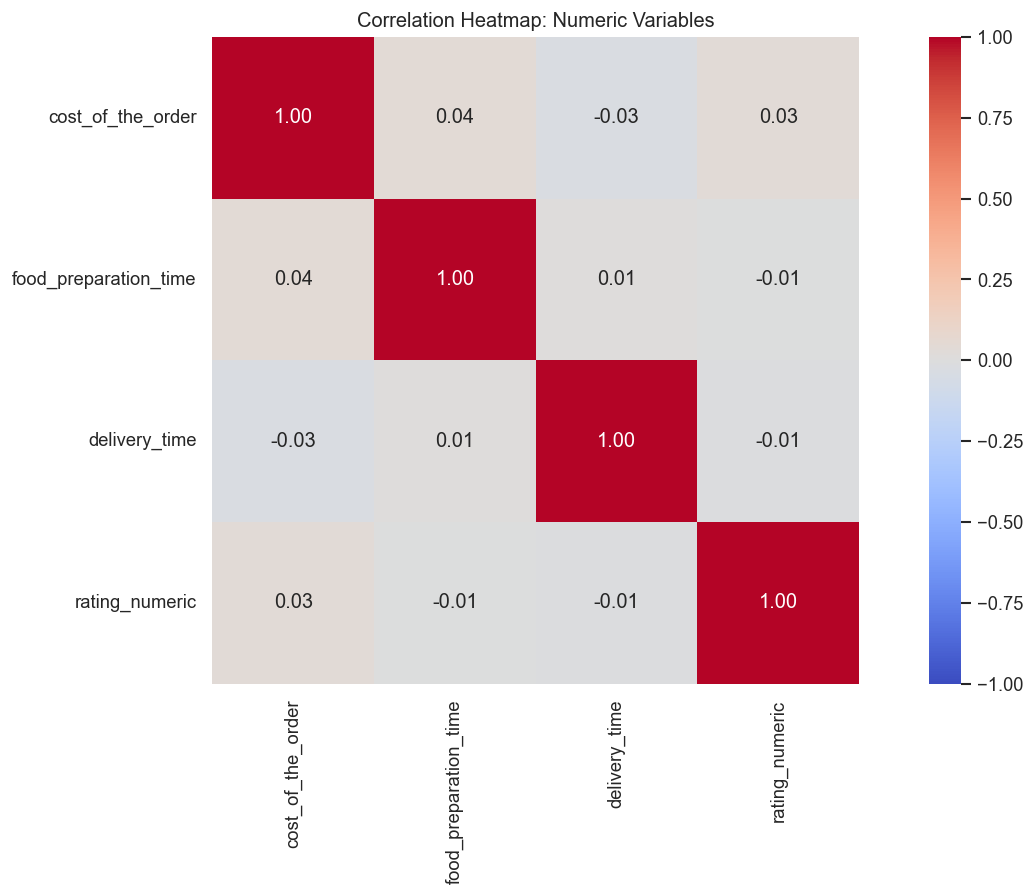

In [284]:
# Heatmap: annot=True shows the correlation value in each cell
# coolwarm palette: red = positive correlation, blue = negative
# vmin/vmax set to -1 and 1 for proper scale context

plt.figure(figsize=(15, 7))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            square=True)

plt.title('Correlation Heatmap: Numeric Variables')
plt.show()

#### Observations

The correlation heatmap confirms what the individual analyses
above showed. There are no meaningful linear relationships 
between the numeric variables in this dataset.

- Cost vs Food Prep Time: 0.04 (Negligible positive)
- Cost vs Delivery Time: -0.03  (Negligible negative) 
- Cost vs Rating: 0.03 (Negligible positive) 
- Food Prep vs Delivery Time: 0.01  (Negligible positive) 
- Food Prep vs Rating: -0.01  (Negligible negative)
- Delivery Time vs Rating: -0.01  (Negligible negative) 

 **Note:** Correlation values are interpreted as follows: 
- ±0.1 to ±0.3 is weak
- ±0.3 to ±0.5 is moderate
- ±0.5 and above is considered strong.

All values here fall well below the weak threshold.

**Key Takeaway**

No single numeric variable in this dataset is a reliable 
predictor of another. Metrics such as preparation time 
and delivery time operate independent of each other and 
of order cost. None of these variables show a meaningful 
relationship with customer ratings. This supports the findings 
that the drivers of customer satisfaction are likely qualitative
factors that are not part of this dataset.

---

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [285]:
# Create a new DataFrame with count and mean of numeric ratings per restaurant
promo_restaurants = df.groupby('restaurant_name')['rating_numeric'].agg(['count', 'mean'])

# Rename columns in new DataFrame for clarity
promo_restaurants.columns = ['rating_count', 'avg_rating']

# Filter for both conditions simultaneously
qualifying = promo_restaurants[
    (promo_restaurants['rating_count'] > 50) & 
    (promo_restaurants['avg_rating'] > 4)
].sort_values('avg_rating', ascending=False)

print(f'There are {len(qualifying)} restaurants that qualify for promotional offer:')
print()

for restaurant, row in qualifying.iterrows():
    print(f'  • {restaurant}')
    print(f'    Ratings received : {int(row["rating_count"])}')
    print(f'    Average rating   : {row["avg_rating"]:.2f}')
    print()


There are 4 restaurants that qualify for promotional offer:

  • The Meatball Shop
    Ratings received : 84
    Average rating   : 4.51

  • Blue Ribbon Fried Chicken
    Ratings received : 64
    Average rating   : 4.33

  • Shake Shack
    Ratings received : 133
    Average rating   : 4.28

  • Blue Ribbon Sushi
    Ratings received : 73
    Average rating   : 4.22



#### Observations

There are 4 restaurants that qualify for the promotional offer because they have more than 50 rated orders and an average rating greater than 4. These restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken.

This suggests that these restaurants have both strong order volume and high customer satisfaction, making them good candidates for the promotion.

---

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [286]:
# Define a function to calculate FoodHub's net revenue per order
# The function should take the order cost as input and return the revenue
# earned per order

def net_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Apply the function to every row in the cost column
# .apply() passes each cost value through net_revenue one at a time

df['revenue'] = df['cost_of_the_order'].apply(net_revenue)

# Sum all revenue values for the total
total_revenue = df['revenue'].sum()

print(f'Total net revenue generated by FoodHub across all orders is: ${total_revenue:,.2f}')

Total net revenue generated by FoodHub across all orders is: $6,166.30


#### Observations

Using a custom function applied across all 1,898 orders, FoodHub's 
total net revenue is **$6,166.30**.

---

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [287]:
# Create a new DataFrame with total time = food preparation time + delivery time
# Create a new column that adds both together

df['total_time'] = df['food_preparation_time'] + df['delivery_time']


In [288]:
# Count orders where total time exceeds 60 minutes
over_60       = len(df[df['total_time'] > 60])
pct_over_60   = (over_60 / len(df)) * 100

under_60      = len(df[df['total_time'] <= 60])
pct_under_60  = (under_60 / len(df)) * 100

print(f'Orders taking more than 60 minutes : {over_60} ({pct_over_60:.2f}%)')
print(f'Orders taking 60 minutes or less   : {under_60} ({pct_under_60:.2f}%)')

Orders taking more than 60 minutes : 200 (10.54%)
Orders taking 60 minutes or less   : 1698 (89.46%)


In [289]:
# Quick summary of the total_time column for context
print(f'Minimum total time : {df["total_time"].min()} minutes')
print(f'Average total time : {df["total_time"].mean():.2f} minutes')
print(f'Maximum total time : {df["total_time"].max()} minutes')

Minimum total time : 35 minutes
Average total time : 51.53 minutes
Maximum total time : 68 minutes


#### Observations

Total time is calculated by combining `food_preparation_time` 
and `delivery_time` into a new `total_time` column.

- **200 orders (10.54%)** take more than 60 minutes from 
  order placement to delivery
- **1,698 orders (89.46%)** are delivered within 60 minutes

The average total time across all orders is approximately 
**51.5 minutes** (27.37 min prep + 24.16 min delivery), 
which sits within the 60-minute threshold.

---


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [290]:
# Calculate the mean delivery time by day type
mean_delivery = (
    df.groupby('day_of_the_week')['delivery_time']
    .mean()
    .round(2)
    .reset_index()
)

# Rename the columns for easier reading
mean_delivery.columns = ['Day Type', 'Average Delivery Time']

# Display the results
mean_delivery

,Day Type,Average Delivery Time
0,Weekday,28.3400
1,Weekend,22.4700


#### Observations

Mean delivery time differs notably between weekdays and weekends:

- **Weekday:** 28.34 minutes
- **Weekend:** 22.47 minutes

Weekend deliveries are on average **5.87 minutes faster** 
than weekday deliveries, an unexpected finding given 
that weekends account for 71.2% of all orders.

This was explored in greater depth earlier, where 
boxplot and IQR analysis showed weekday delivery is also more 
consistent (IQR 5 min) while weekend delivery has more 
variability (IQR 8.5 min).

---

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

### Conclusions

The following key findings emerged from the analysis of 
FoodHub's order data:

#### Weekend Demand Dominance
71.2% of all orders are placed on weekends. This imbalance should be
analyzed further to understand what is driving this difference, 
how it is impacting the business and what can be done to drive
more volume on the Week Days.


#### A Few Restaurants/Cuisines Drive Order Volume
The top 5 restuarants account for 34% of all orders. Shake Shack accounts for
12% (219) orders alone.

On the Weekends, American and Japanese cuisines together represent over half of 
all platform activity (56%)

#### Cost of Orders
The majority of orders are $20 or less (70%). Analyze this further
to underand the volume at a more granular level and see if the 
current compensation structure aligns with the volume.


#### No Ratings Driver
Delivery time, food preparation time, and order cost 
show no meaningful correlation with customer ratings. 
Another measure like Food quality, which is not captured 
in this dataset could potentially be a factor in satisfaction,
worth exploring.


#### Significant Unrated Orders
With **38.8%** of orders are unrated**, there is
a significant gap in customer feedback data. This limits 
FoodHub's ability to assess service quality and 
identify additional opportunities for improvement.

---

### Recommendations

#### Deep Dive Weekend Activity
With 71.2% of orders on weekends, FoodHub should 
look deeper into what is driving demand. The data shows 
weekends are already have quicker delivery times 
(22.47 min vs 28.34 min on weekdays) and higher volume.
Can anything on the weekends be implemented during the
weekday.

#### Review Compensation Structure
Dive deeper into the cost of orders and see if it aligns with
the compensation structure. With 70% of orders at $20 or
less, determine how to increase volume of orders greater
than $20 or adjust compensation to increase revenues on lower
priced orders.


#### Implement a Rating Incentive Program
38.8% of customers did not rate their order. FoodHub 
should review their ratings questions and processes to see if they
can increase the volume of responses. Perhaps 
incentives (e.g. discount on next order) to encourage 
ratings. This could give additional insight on overall
customer satisfaction.


#### Collect Food Quality Data
Since none of the current metrics correlate
with ratings, introducing other variables such as
food quality could provide more insight into 
satisfaction. FoodHub should explore adding quality 
indicators to its platform to better understand what 
drives customer experience.


#### Drive Weekday Demand
With only 28.8% of orders on weekdays, there is 
opportunity to increase order volume Monday through Friday. 
Things like targeted promotions for students and professionals 
during weekday lunch and dinner hours could increase 
demand and across the week and increase total revenue.

---

## Appendix: Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

---